# ML Prognostic Classifier using Pan-Cancer Signatures (TCGA - OV, LUSC, SKCM, KICH, COAD, READ, LUAD, BRCA, KIRC, KIRP)

### Goal
Build and validate Machine Learning Prognostic Classifiers evaluating **each 4-cancer combination separately**.

### Interpretation
- **Cox Proportional Hazards C-index**: Establishes baseline linear survival predictive power.
- **Random Forest & MLP ROC-AUC**: Evaluates non-linear and interactive predictive power for 5-year binary overall survival.
- **Kaplan-Meier High vs Low Risk**: Stratifies patients based on machine learning risk scores.


In [ ]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import glob

# ML & Survival Modeling
from lifelines import CoxPHFitter, KaplanMeierFitter
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import roc_auc_score, roc_curve

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 300


## 1. Data Loading

We load the cleaned TCGA clinical and expression data and merge them into a unified dataset.


In [ ]:
database = "tcga"
cancers = ['ov', 'lusc', 'skcm', 'kich', 'coad', 'read', 'luad', 'brca', 'kirc', 'kirp']

data_dir = '../input/tcga'
if not os.path.exists(data_dir):
    data_dir = 'input/tcga'

clin_dfs = []
expr_dfs = []

for cancer in cancers:
    clin_path = os.path.join(data_dir, f'{cancer}_clinical.csv')
    expr_path = os.path.join(data_dir, f'{cancer}_expression.csv')
    
    c_df = pd.read_csv(clin_path, low_memory=False)
    e_df = pd.read_csv(expr_path, low_memory=False)
    
    c_df['CANCER_TYPE'] = cancer.upper()
    
    # Preprocessing Expression for ML format
    e_df = e_df.drop(columns=['Entrez_Gene_Id'], errors='ignore')
    if 'Hugo_Symbol' in e_df.columns:
        e_df = e_df.set_index('Hugo_Symbol').T
    else:
        e_df = e_df.set_index(e_df.columns[0]).T
        
    e_df.index.name = 'SAMPLE_ID' if 'SAMPLE_ID' in c_df.columns else 'PATIENT_ID'
    e_df = e_df.reset_index()
    
    if database.lower() == 'tcga':
        # Align TCGA IDs
        e_df[e_df.columns[0]] = e_df[e_df.columns[0]].apply(lambda x: str(x)[:12])
        
    clin_dfs.append(c_df)
    expr_dfs.append(e_df)

# Pan-Cancer Merge
clin_df = pd.concat(clin_dfs, ignore_index=True)
expr_df = pd.concat(expr_dfs, ignore_index=True)

merge_key = 'SAMPLE_ID' if 'SAMPLE_ID' in clin_df.columns else 'PATIENT_ID'
df = pd.merge(clin_df, expr_df, on=merge_key, how='inner')
df = df.drop_duplicates(subset=['PATIENT_ID'])
print(f"Final dataset shape: {df.shape}")

df['5yr_survival'] = np.where((df['OS_MONTHS'] >= 60), 1, 
                              np.where((df['event'] == 1) & (df['OS_MONTHS'] < 60), 0, np.nan))

# Glob all signatures to evaluate
try:
    from pan_cancer_config import ANALYSIS_SUFFIX
except ImportError:
    ANALYSIS_SUFFIX = ''

meta_dir = '../output/pan_cancer_meta_results'
if not os.path.exists(meta_dir):
    meta_dir = 'output/pan_cancer_meta_results'
    
signature_files = glob.glob(os.path.join(meta_dir, f"pan_cancer_signature_*_6MetCan_500k.csv"))
if not signature_files:
    strict_sig = os.path.join(meta_dir, f"pan_cancer_conserved_genes_6MetCan_500k.csv")
    if os.path.exists(strict_sig):
        signature_files = [strict_sig]

genes_dict = {}
if not signature_files:
    print("No signatures found. Falling back to dynamic genes list.")
    if 'scripts' not in sys.path and '.' not in sys.path:
        sys.path.append('scripts')
        sys.path.append('.')
    from dynamic_genes import get_dynamic_genes
    genes_dict["Dynamic_All"] = get_dynamic_genes(base_dir='..')
else:
    for sig_file in signature_files:
        sig_name = os.path.basename(sig_file).replace('.csv', '').replace('pan_cancer_signature_', '')
        df_sig = pd.read_csv(sig_file)
        genes_dict[sig_name] = df_sig.iloc[:, 0].tolist()

print(f"\nFound {len(genes_dict)} combinations to evaluate.")


Final dataset shape: (4419, 60664)

Found 7 combinations to evaluate.



Evaluating Signature: Kidney_Breast_Colorectal_Lung_Melanoma_6MetCan_500k
Skipping Kidney_Breast_Colorectal_Lung_Melanoma_6MetCan_500k: Not enough valid genes (1) found in expression dataset.

Evaluating Signature: Breast_Colorectal_Ovarian_Lung_Melanoma_6MetCan_500k
Proceeding with 4 genes.
Train size: 3535
Test size: 884
Selected Optimal Penalizer: 0.01
(CV C-index: 0.545)
Cox PH C-index on TEST set: 0.543

Evaluating Signature: Kidney_Breast_Ovarian_Lung_Melanoma_6MetCan_500k
Skipping Kidney_Breast_Ovarian_Lung_Melanoma_6MetCan_500k: Not enough valid genes (1) found in expression dataset.

Evaluating Signature: Kidney_Breast_Colorectal_Ovarian_Lung_6MetCan_500k
Proceeding with 4 genes.
Train size: 3535
Test size: 884
Selected Optimal Penalizer: 0.05
(CV C-index: 0.537)
Cox PH C-index on TEST set: 0.544

Evaluating Signature: Kidney_Colorectal_Ovarian_Lung_Melanoma_6MetCan_500k
Proceeding with 3 genes.
Train size: 3535
Test size: 884
Selected Optimal Penalizer: 0.1
(CV C-index: 0.55

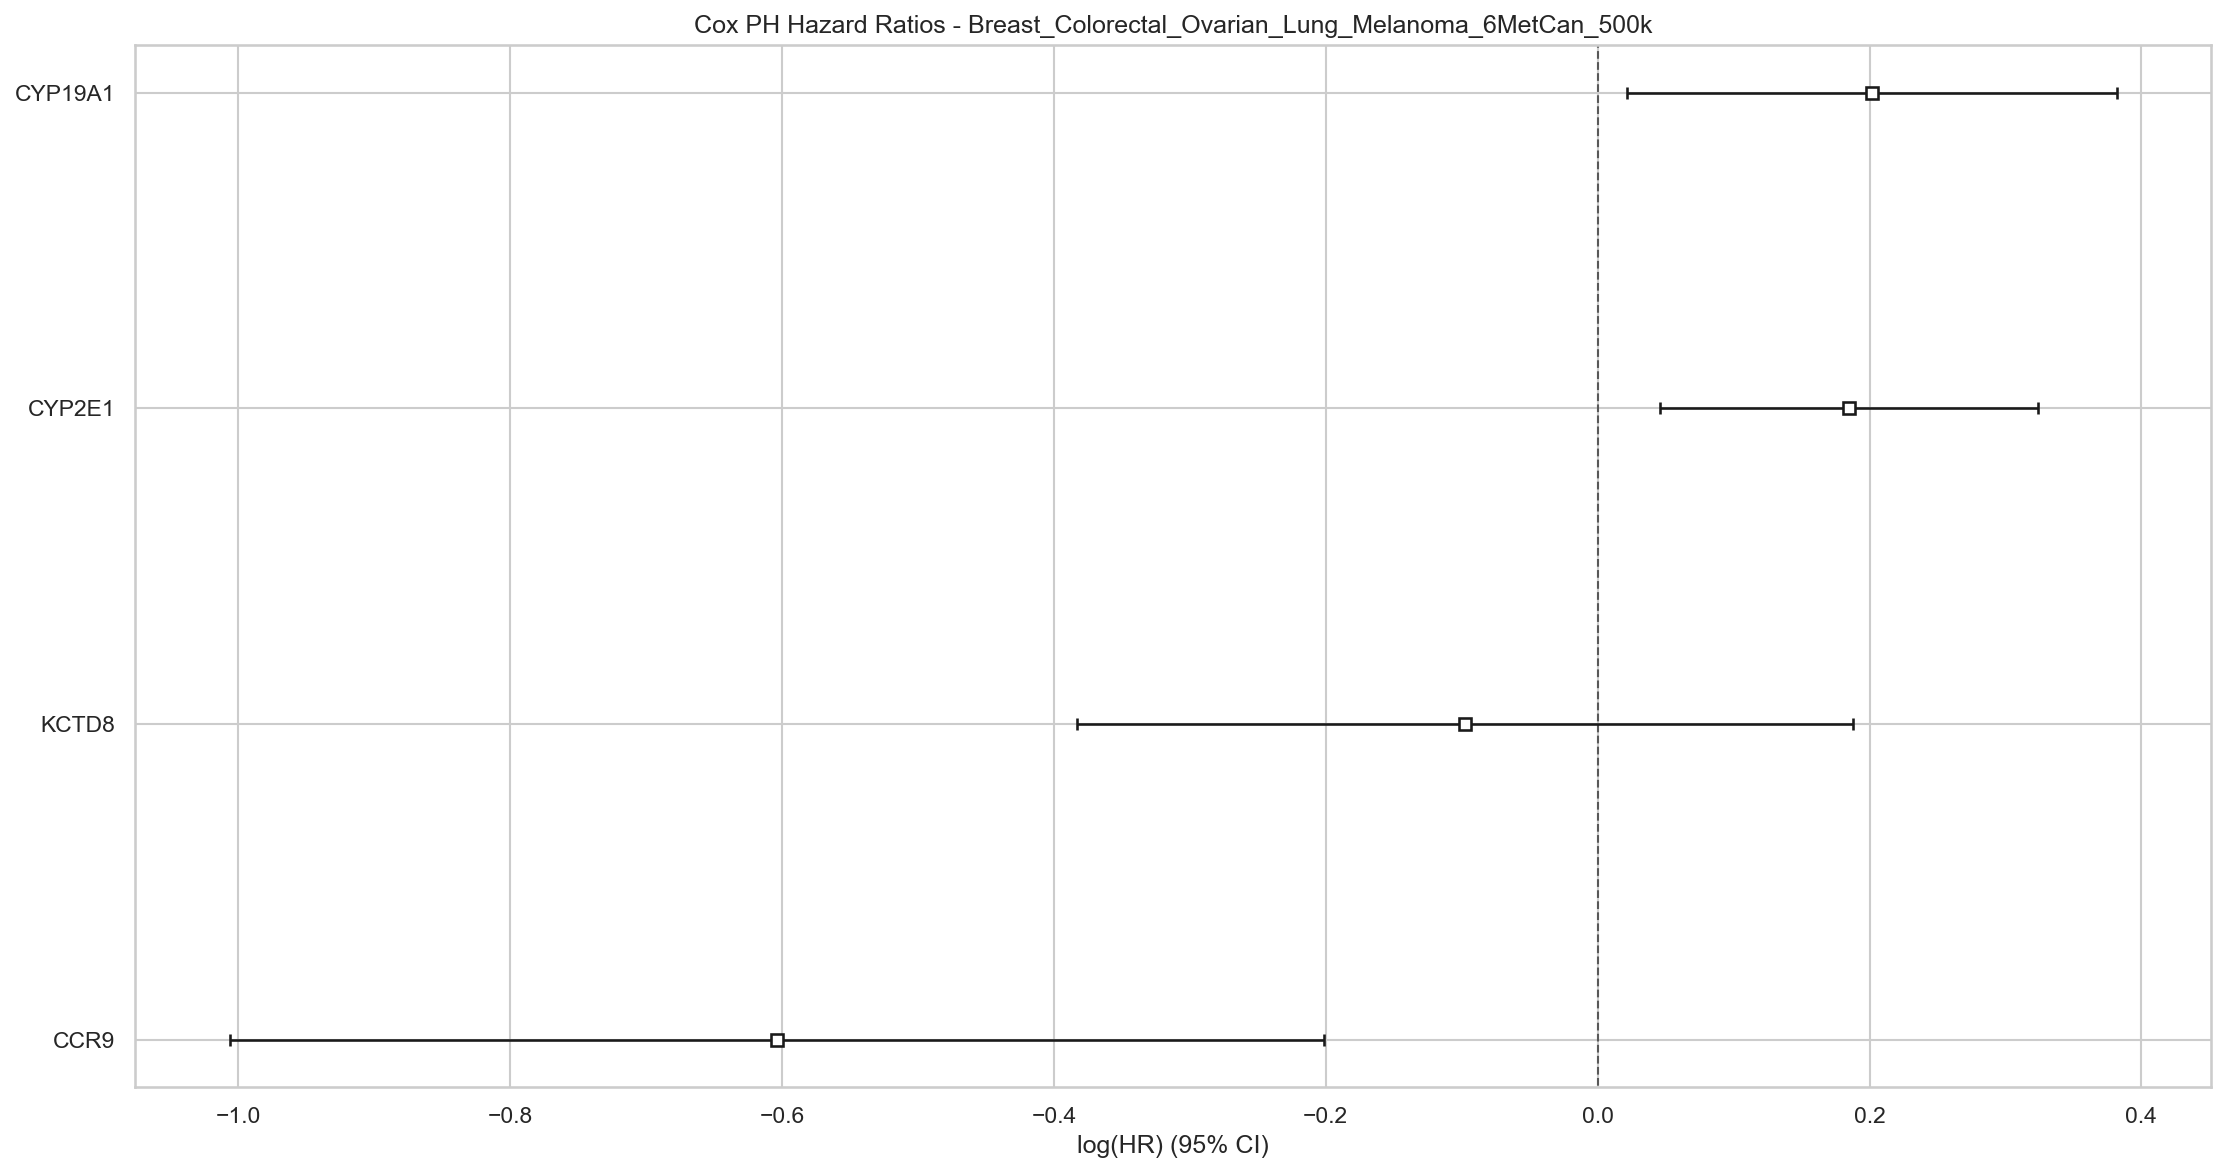

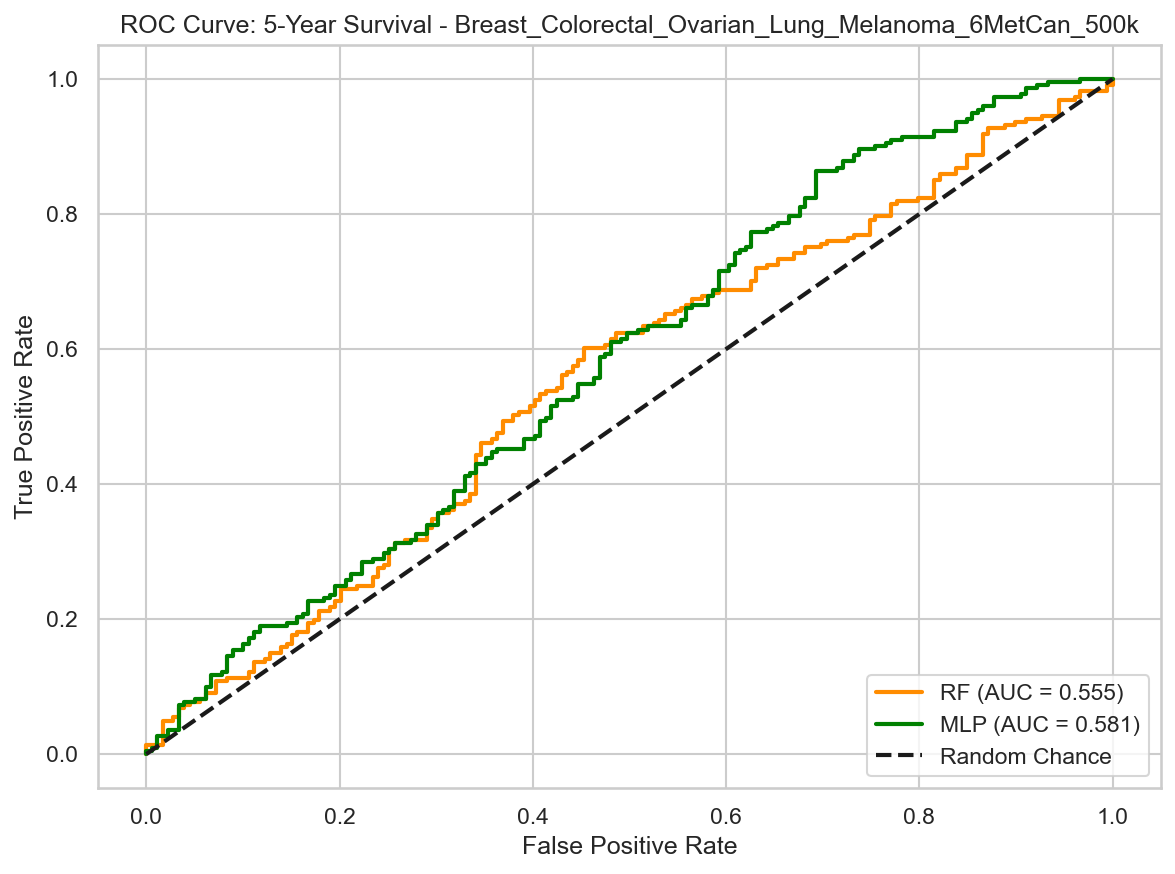

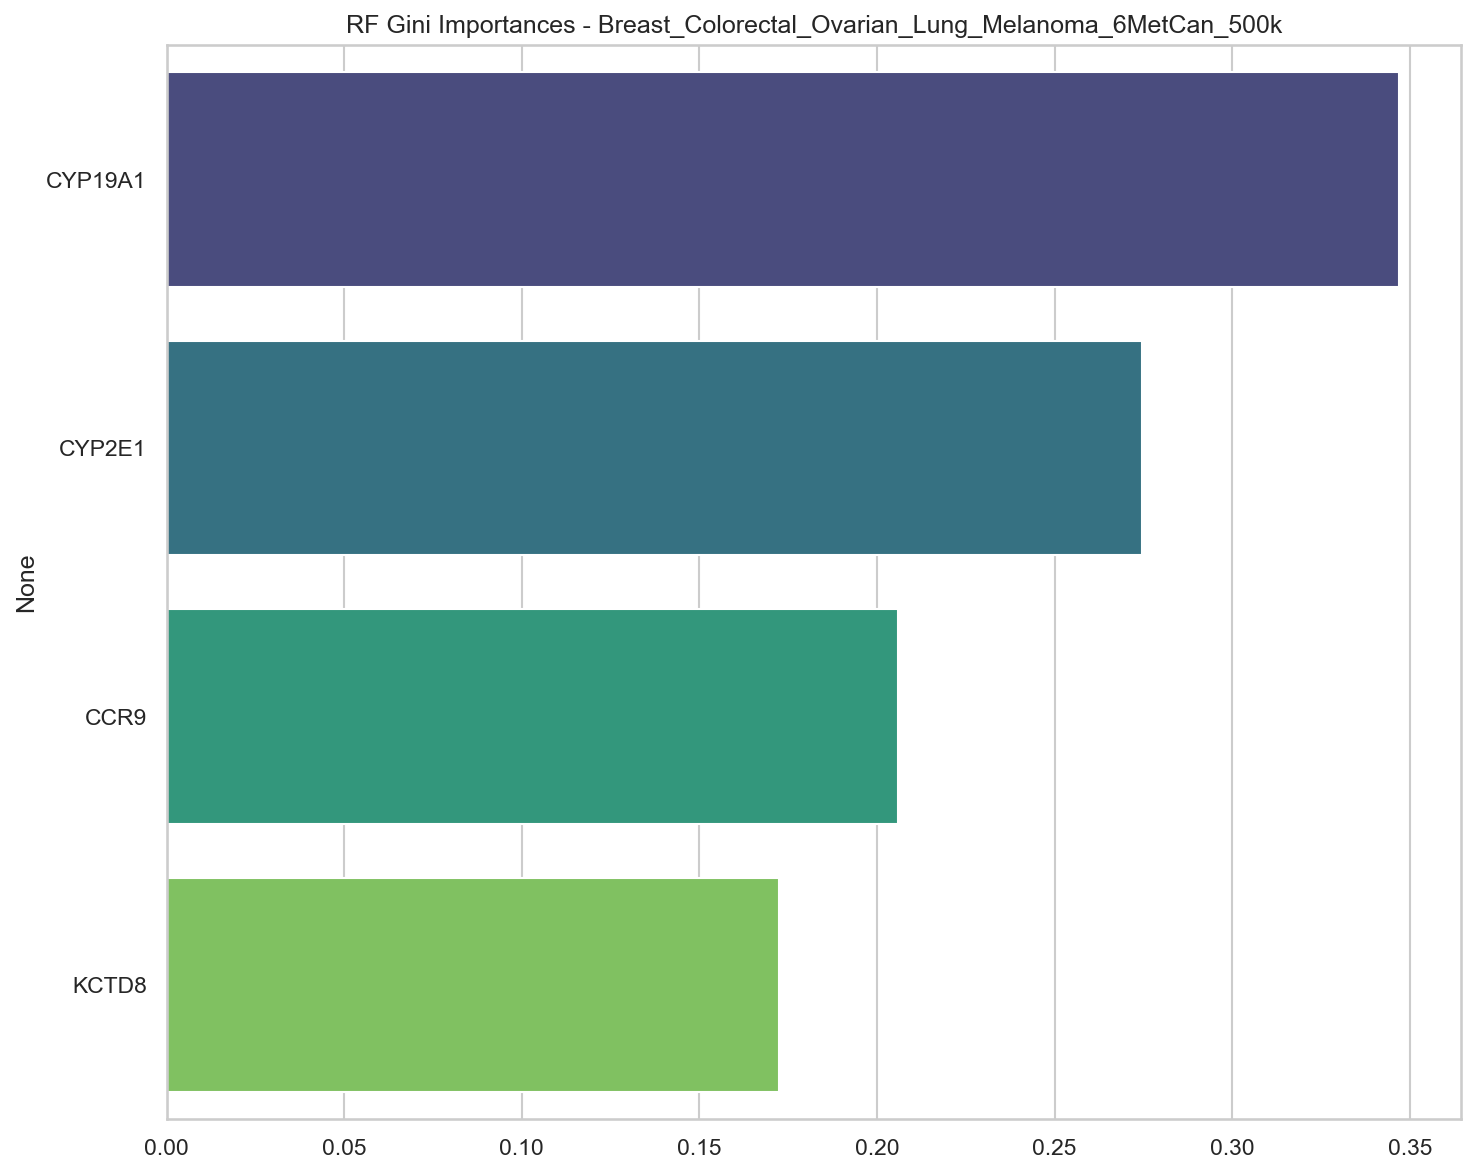

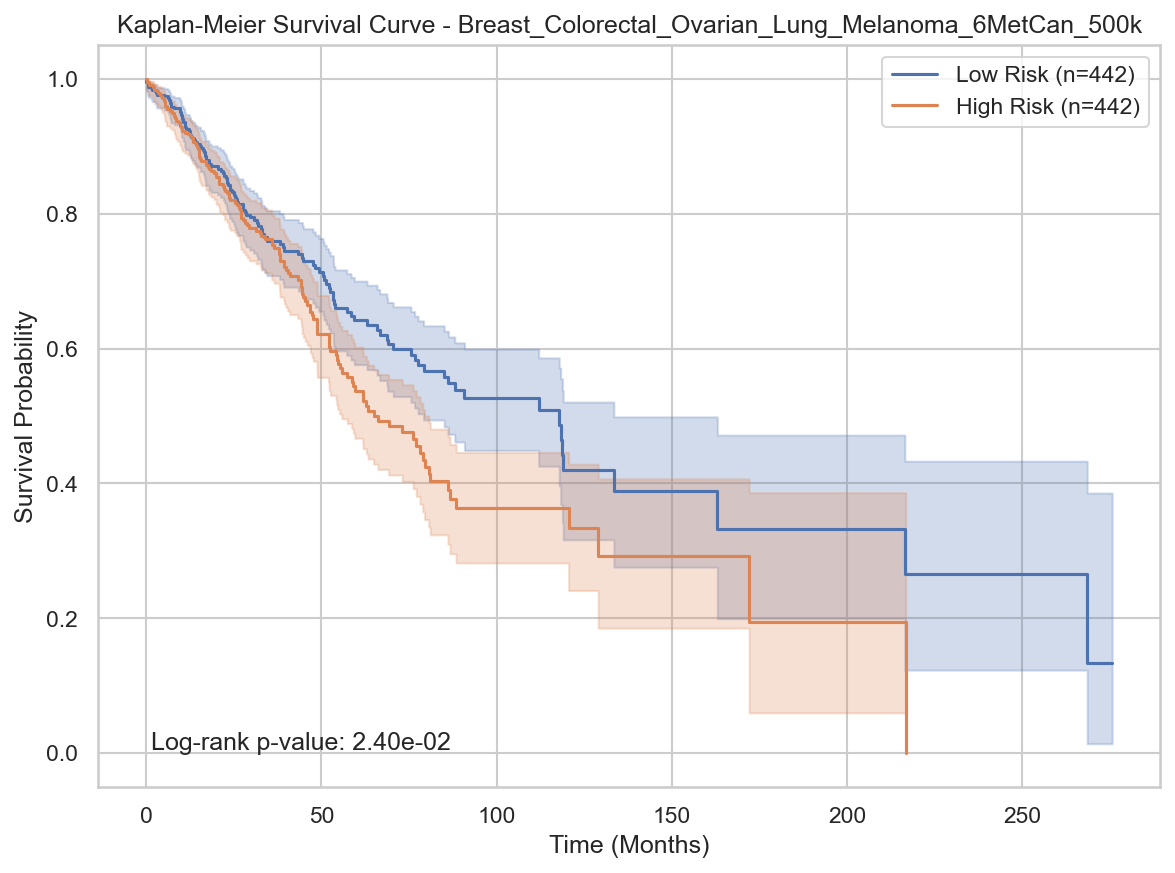

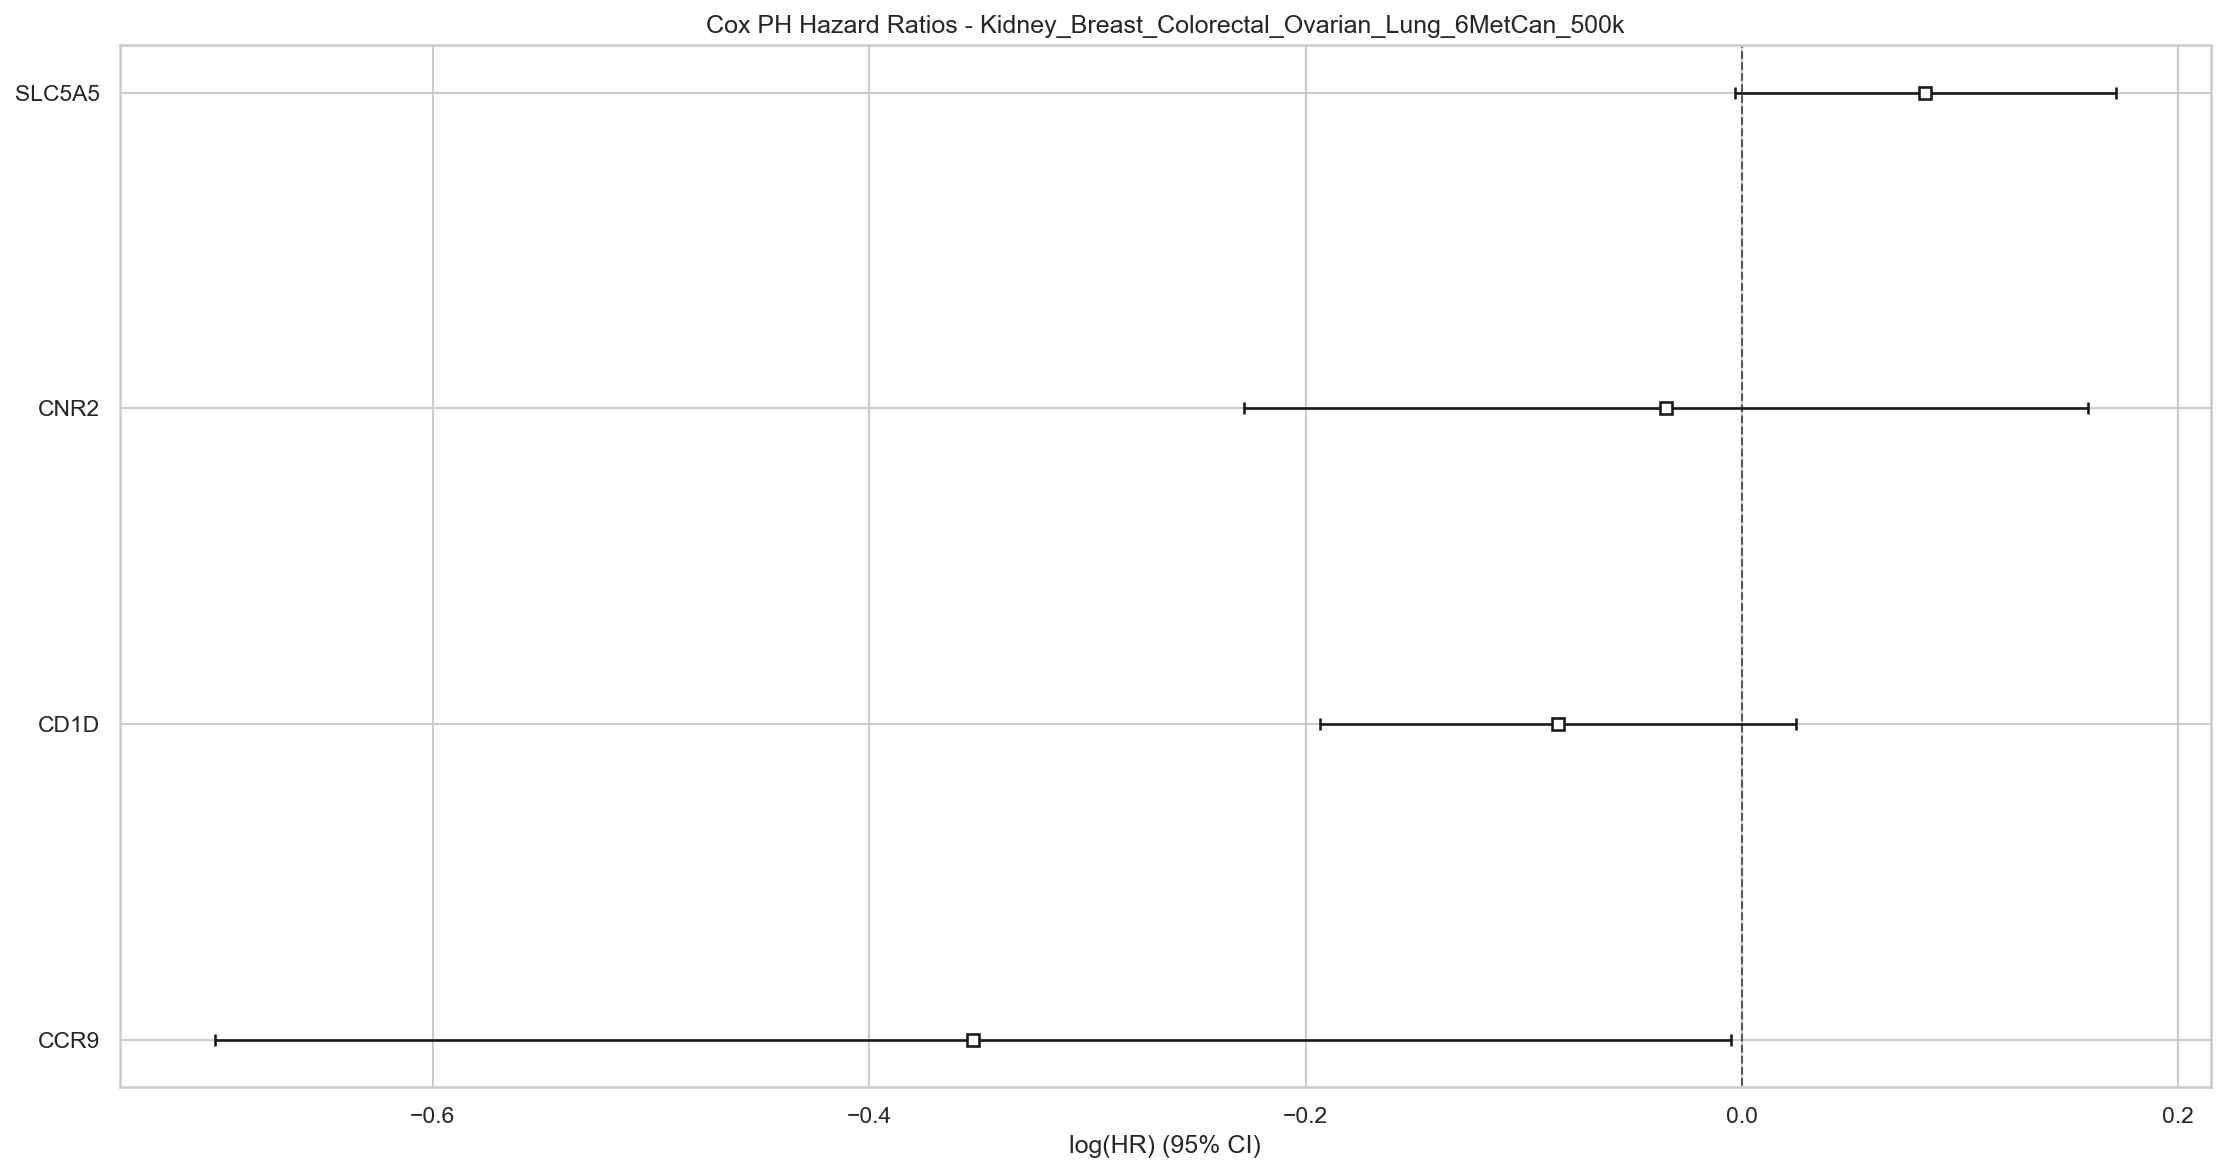

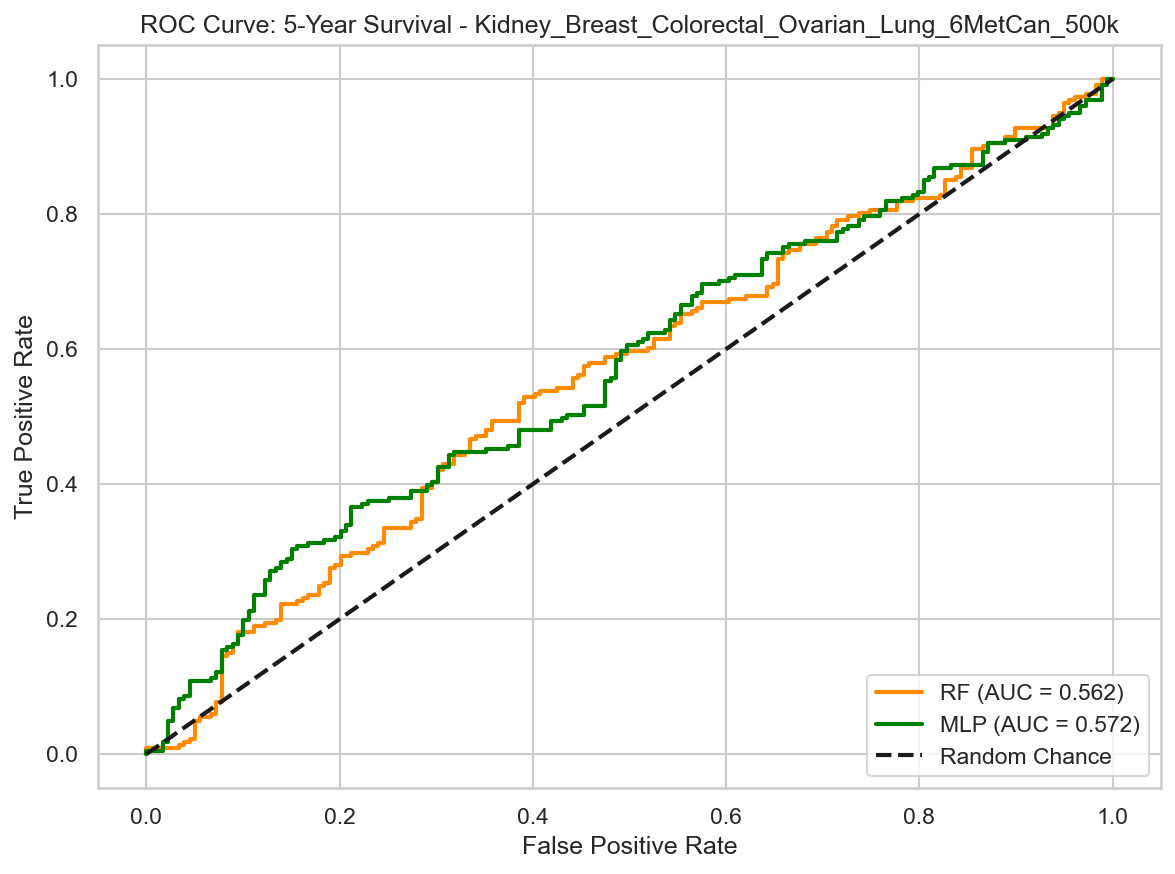

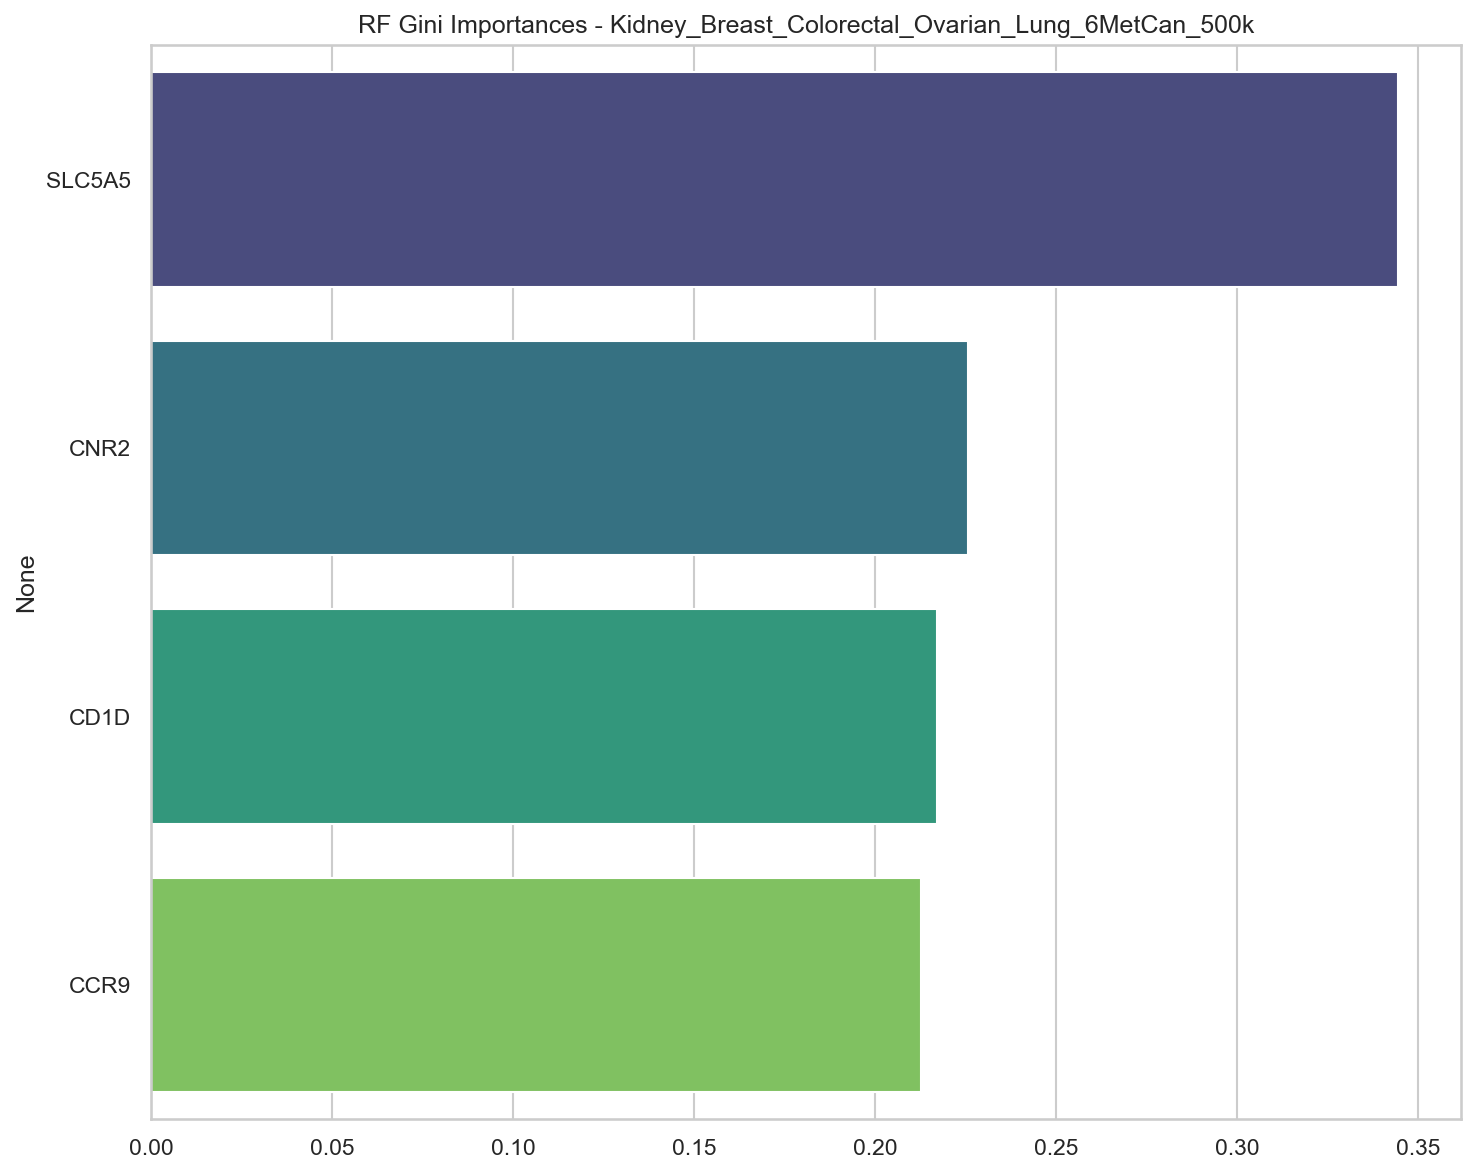

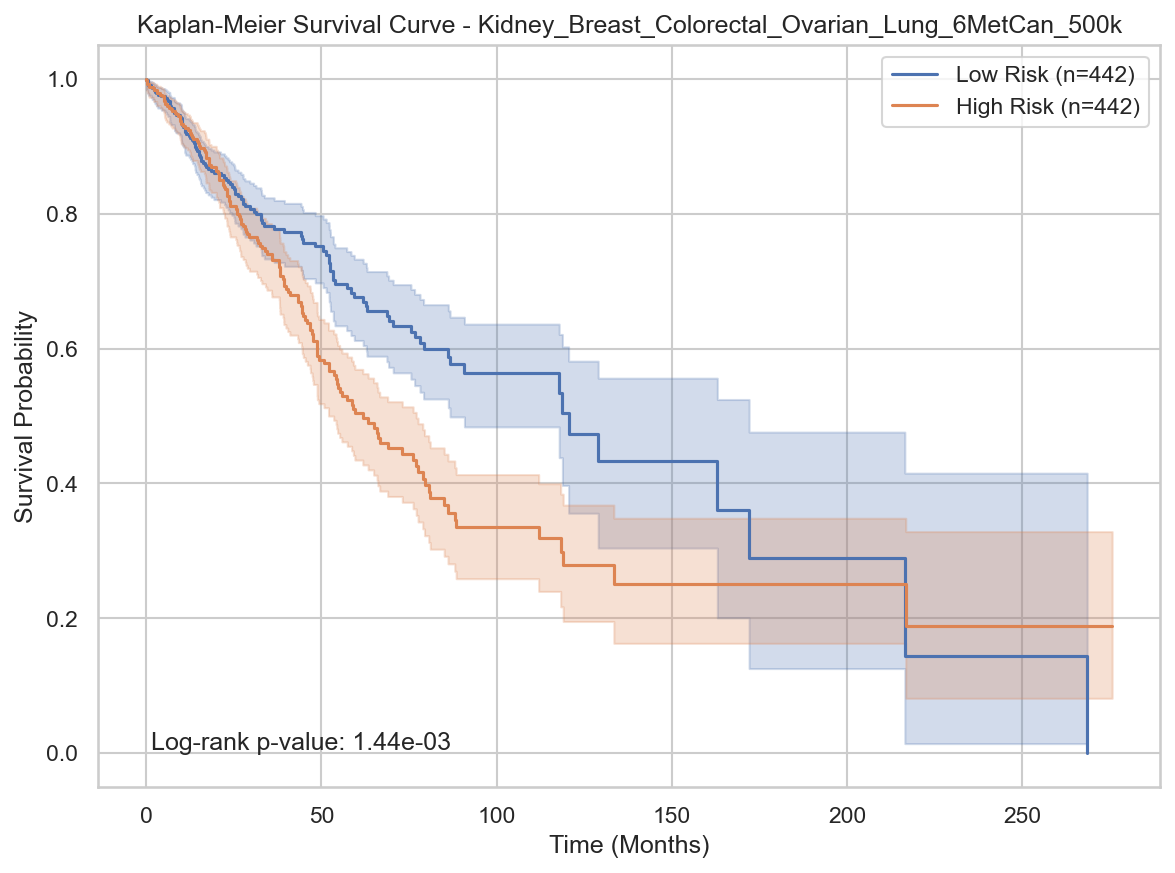

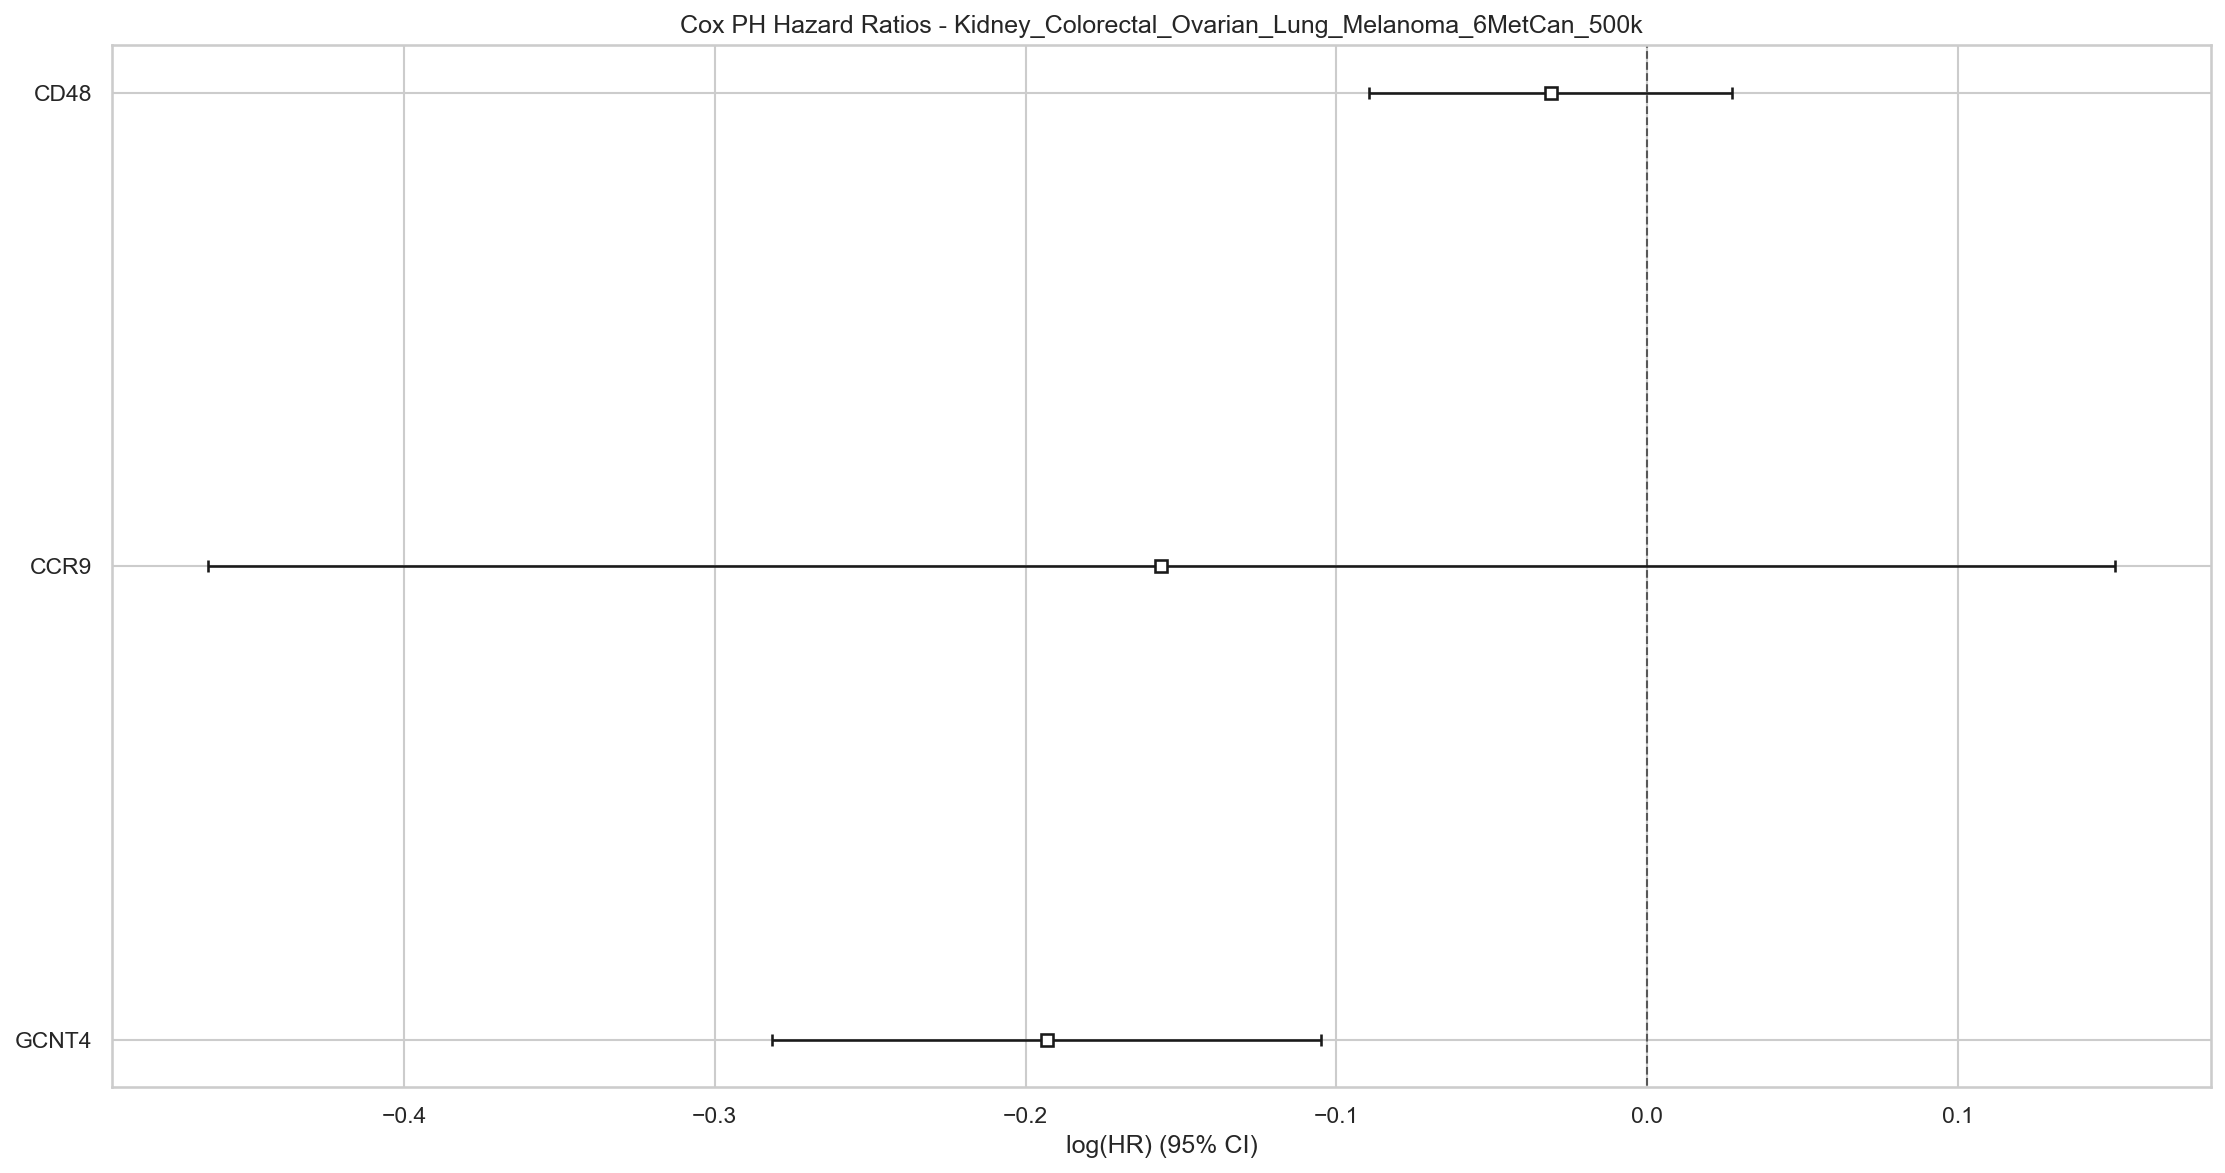

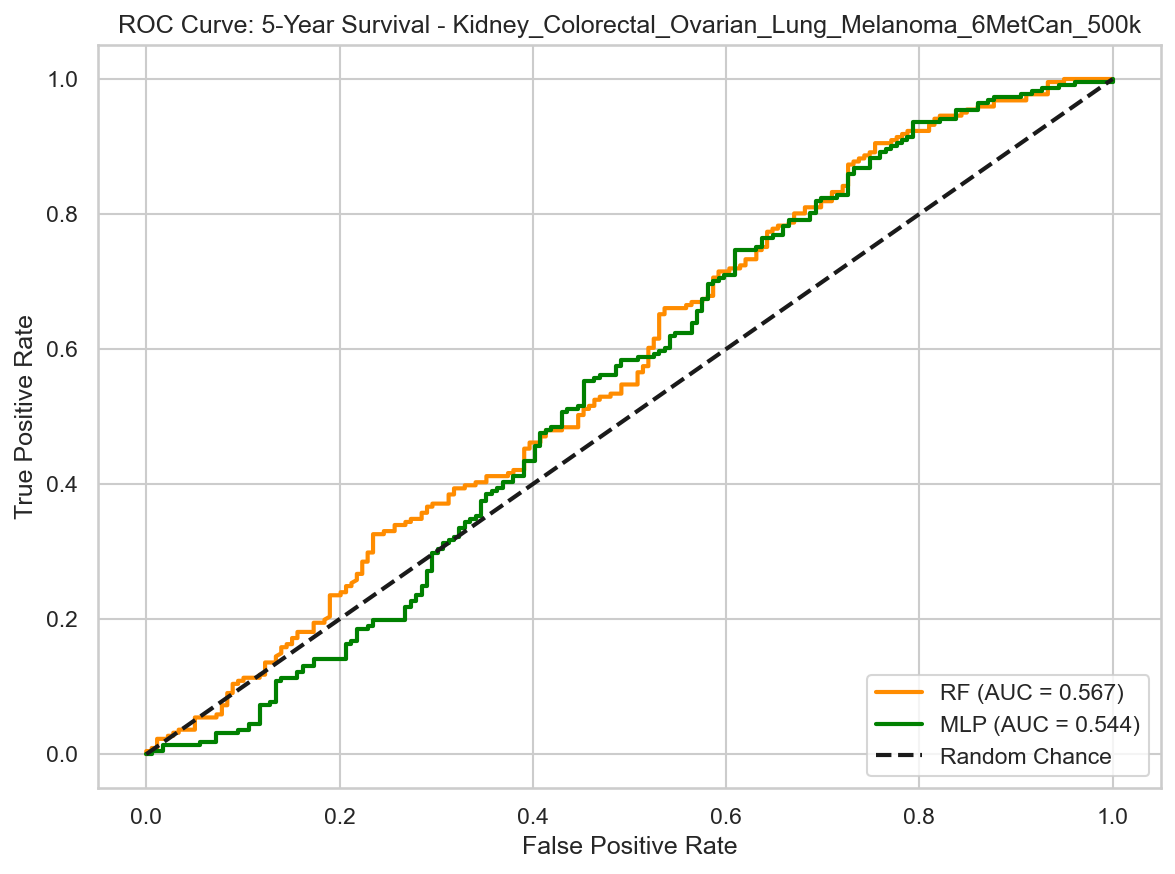

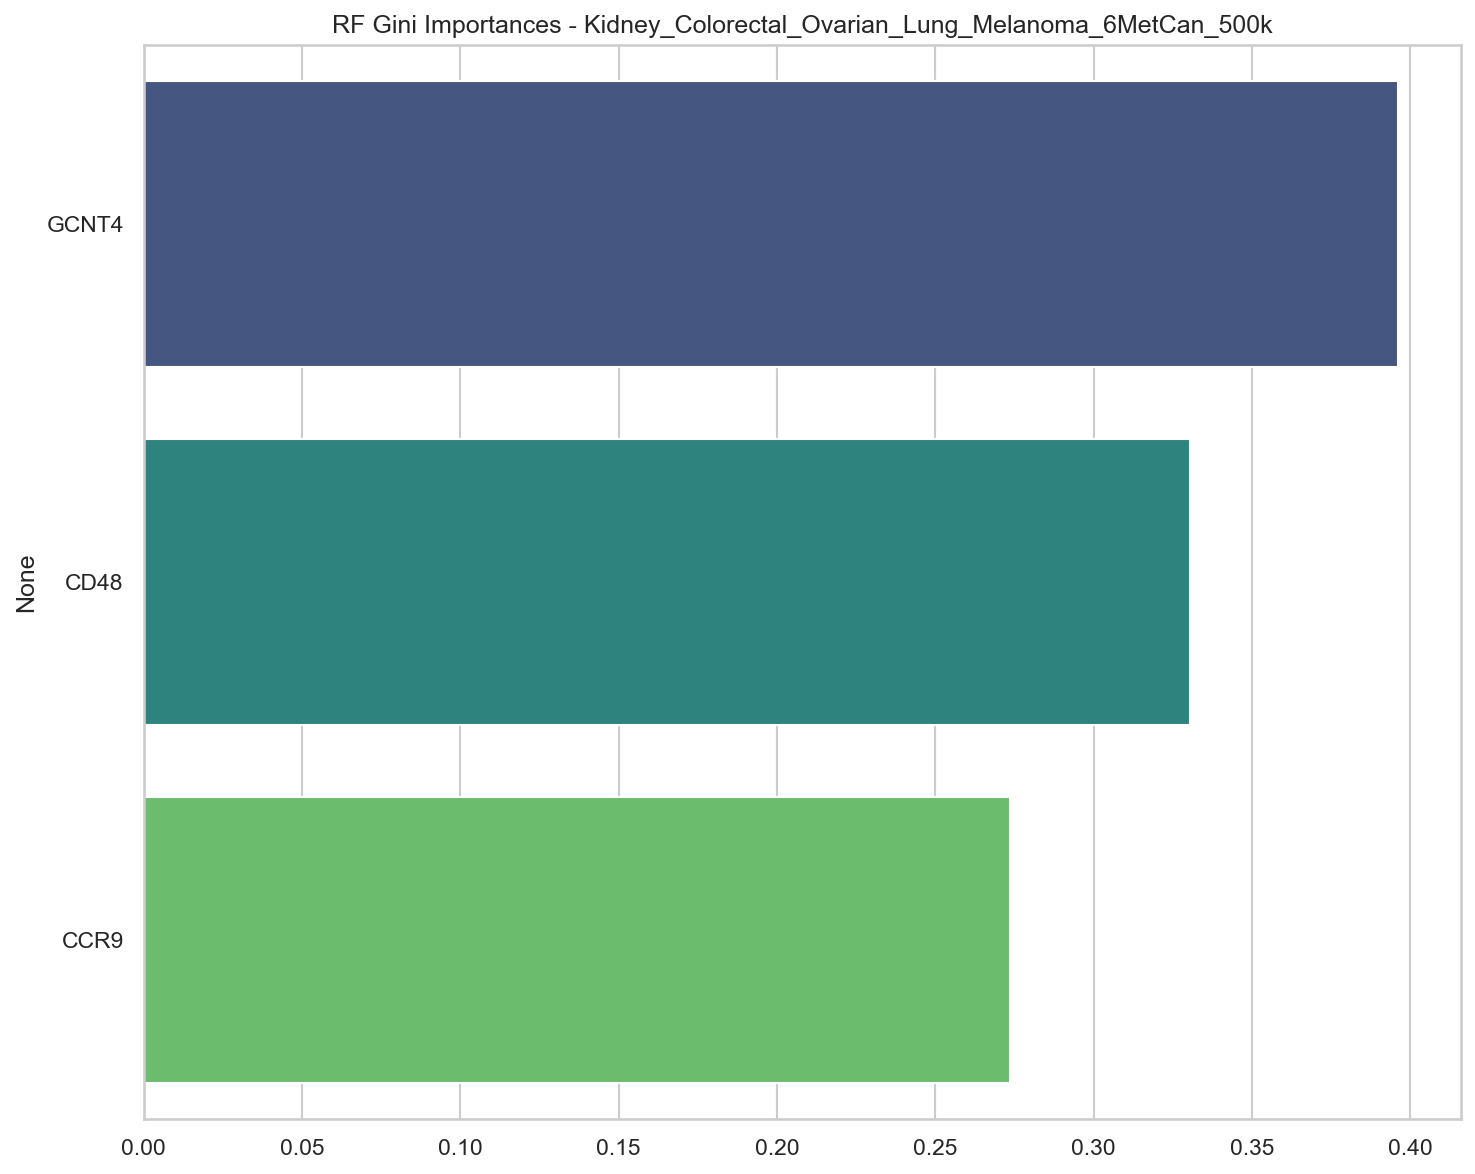

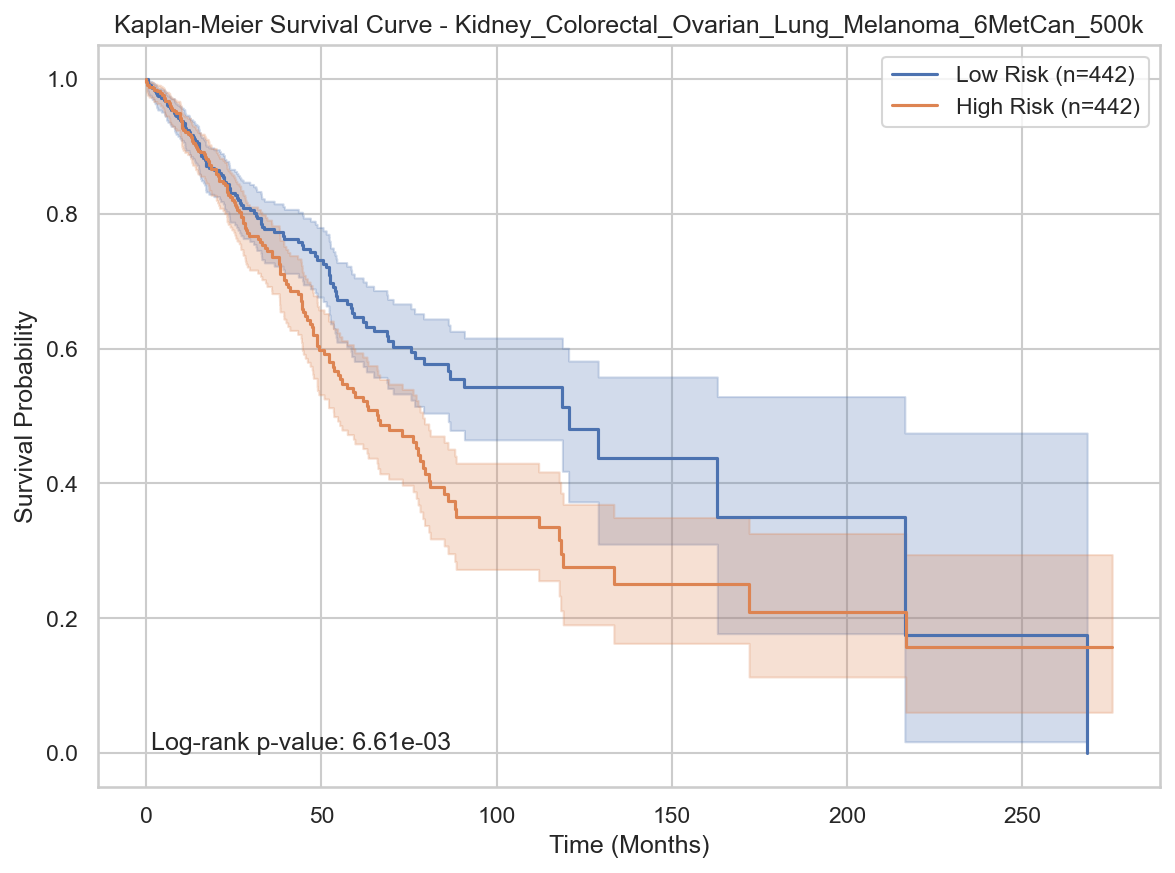

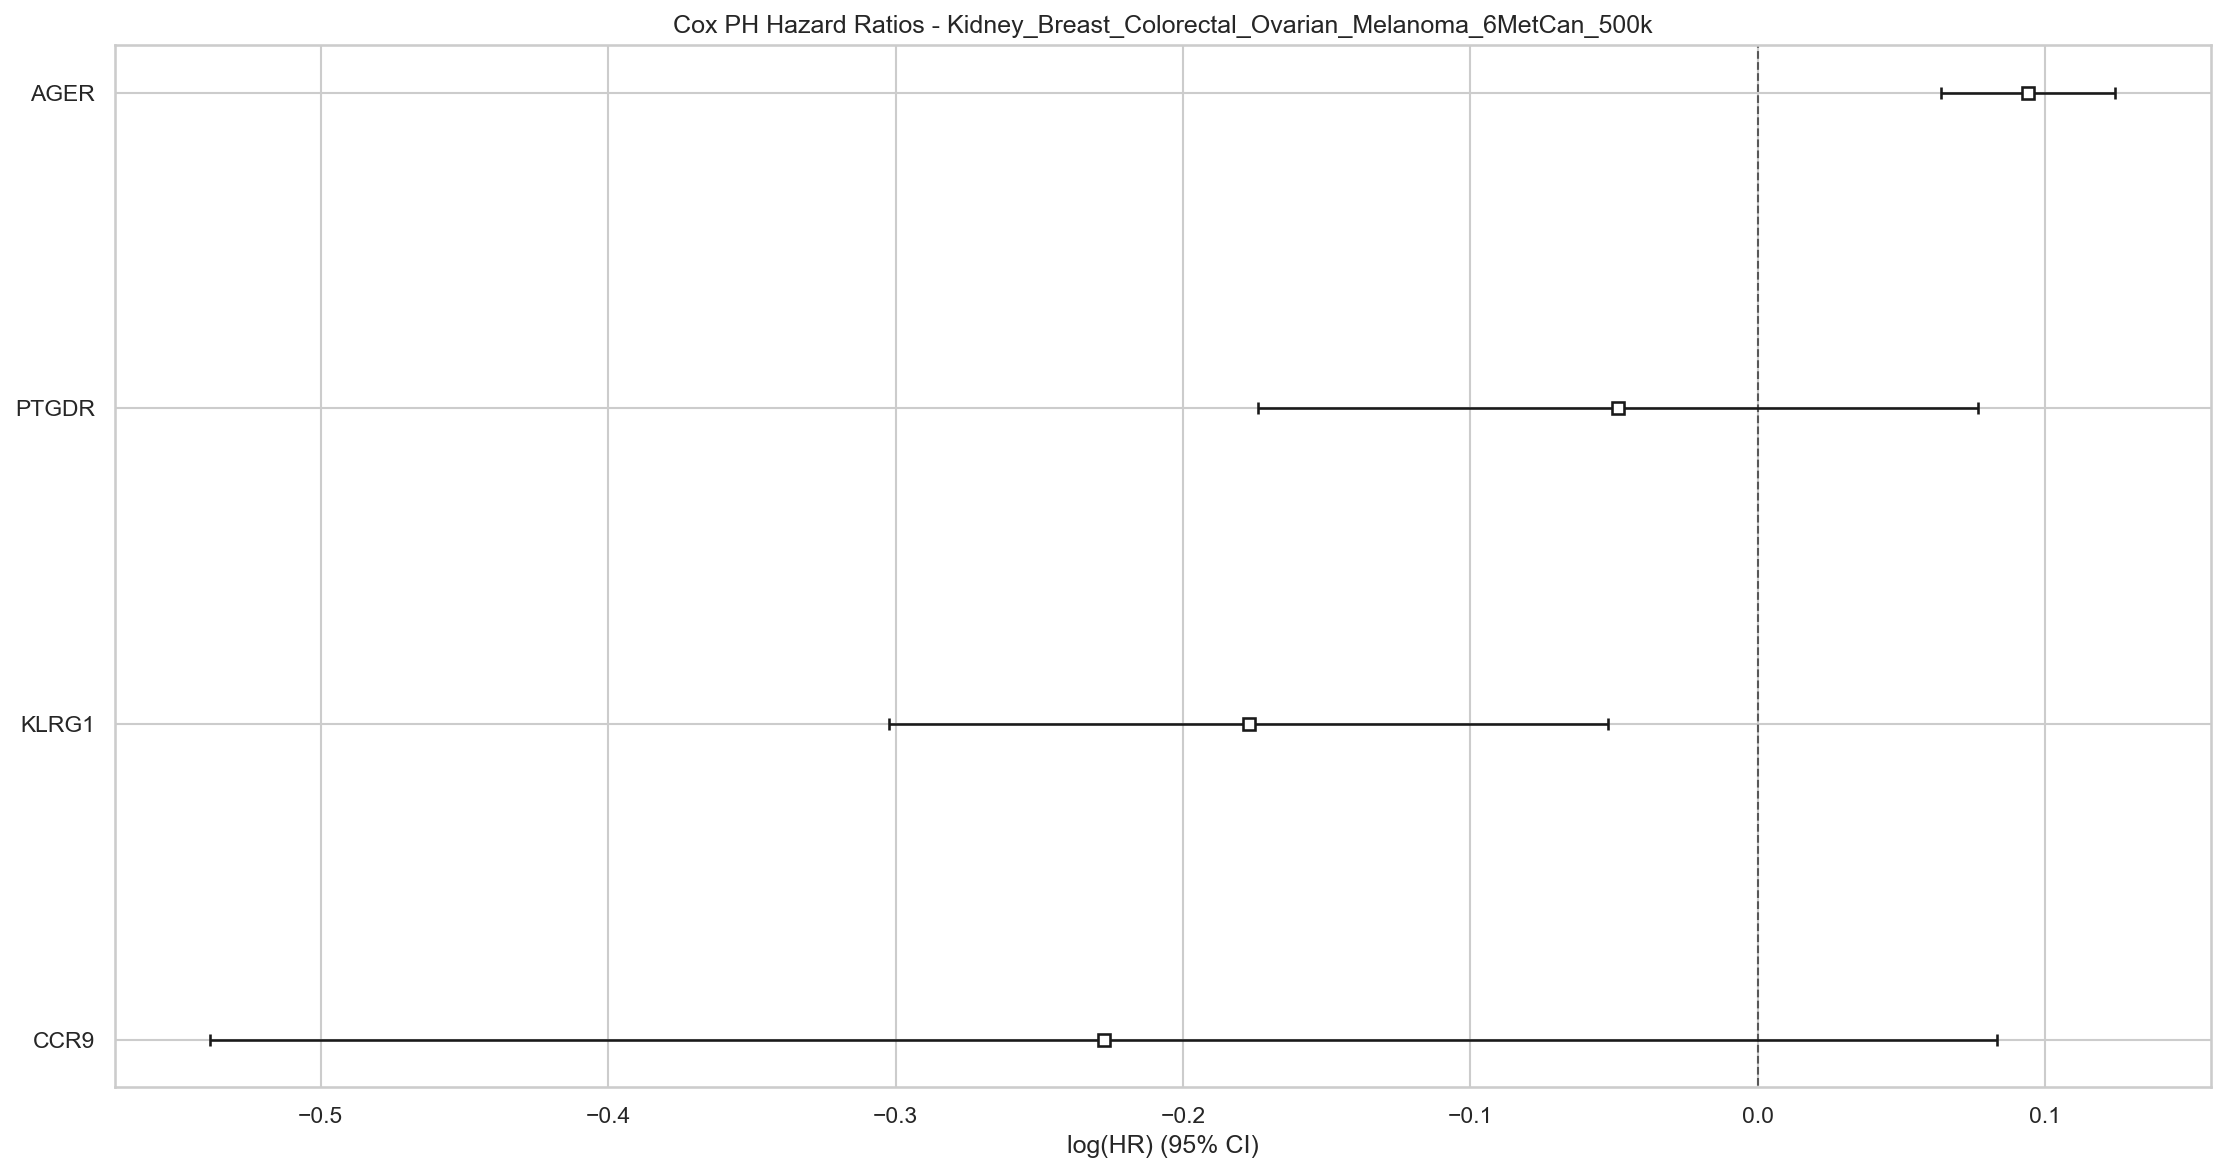

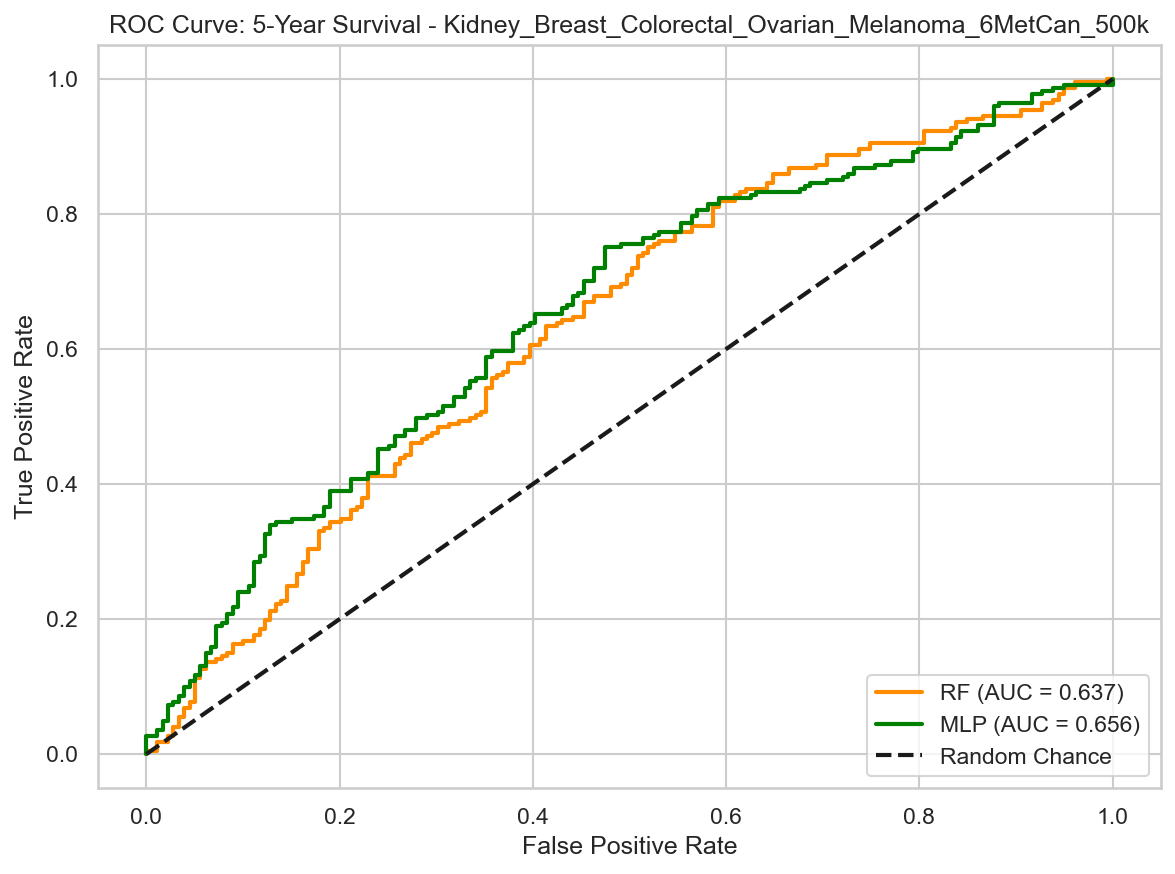

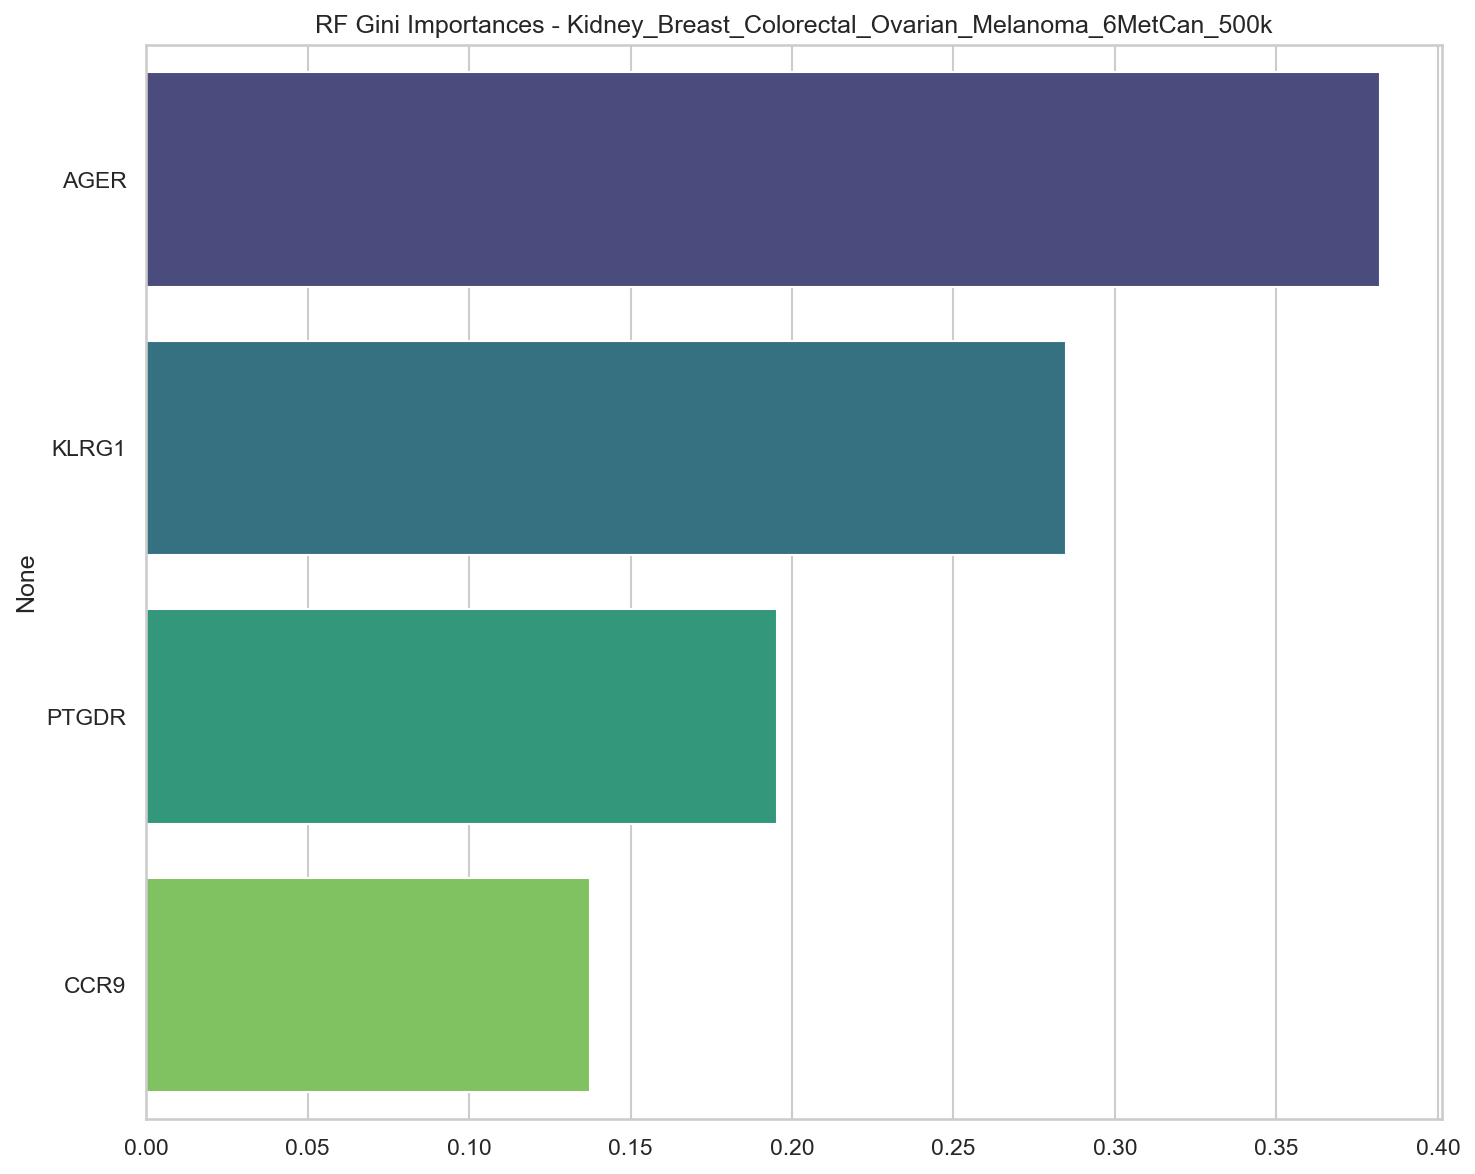

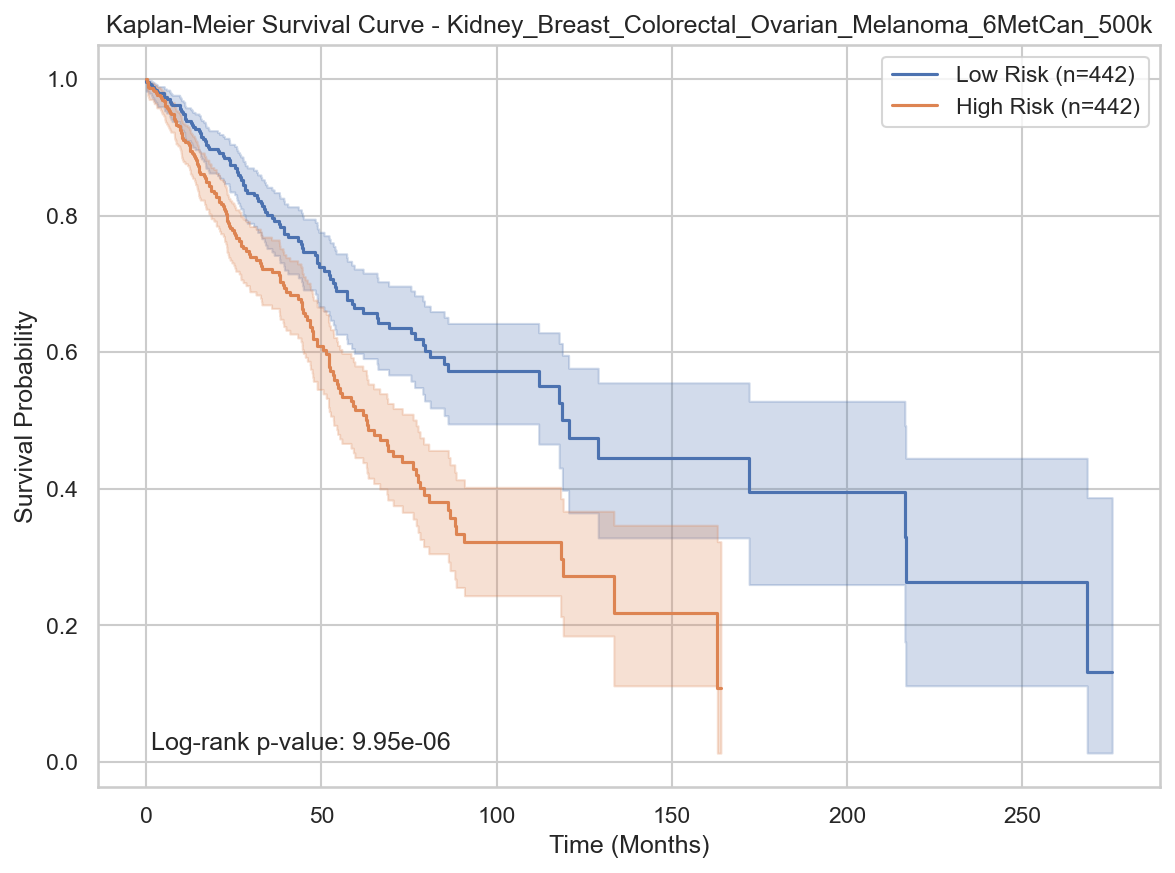

In [ ]:
# Loop through signatures and evaluate models
out_base_dir = f'../output/ml_prognostic_results/{database}/{"_".join(cancers)}'
os.makedirs(out_base_dir, exist_ok=True)

all_metrics = []

for sig_name, genes in genes_dict.items():
    print("\n" + "="*80)
    print(f"Evaluating Signature: {sig_name}")
    print("="*80)
    
    present_genes = [g for g in genes if g in df.columns]
    if len(present_genes) < 2:
        print(f"Skipping {sig_name}: Not enough valid genes ({len(present_genes)}) found in expression dataset.")
        continue
        
    num_genes = len(present_genes)
    print(f"Proceeding with {num_genes} genes.")
    
    out_dir = os.path.join(out_base_dir, sig_name)
    os.makedirs(out_dir, exist_ok=True)
    
    X_train, X_test, y_train, y_test = train_test_split(df[present_genes], df, test_size=0.2, random_state=42)
    
    # 1. Drop zero-variance
    variances = X_train.var()
    zero_var_cols = variances[variances < 1e-5].index
    if len(zero_var_cols) > 0:
        X_train = X_train.drop(columns=zero_var_cols)
        X_test = X_test.drop(columns=zero_var_cols)

    # 2. Drop collinear
    corr_matrix = X_train.corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    to_drop = [column for column in upper.columns if any(upper[column] > 0.95)]
    if len(to_drop) > 0:
        X_train = X_train.drop(columns=to_drop)
        X_test = X_test.drop(columns=to_drop)
        
    cph_train = pd.concat([X_train, y_train[['OS_MONTHS', 'event']]], axis=1)
    
    # Find penalizer
    from lifelines.utils import k_fold_cross_validation
    penalizers = [0.01, 0.05, 0.1, 0.5, 1.0]
    best_score = -np.inf
    best_penalizer = 0.1
    for p in penalizers:
        cph_cv = CoxPHFitter(penalizer=p, l1_ratio=0.1)
        try:
            scores = k_fold_cross_validation(cph_cv, cph_train, duration_col='OS_MONTHS', event_col='event', k=5, scoring_method="concordance_index")
            if np.mean(scores) > best_score:
                best_score = np.mean(scores)
                best_penalizer = p
        except:
            pass
            
    if best_score == -np.inf: best_penalizer = 1.0
    
    print(f"Train size: {len(X_train)}")
    print(f"Test size: {len(X_test)}")
    print(f"Selected Optimal Penalizer: {best_penalizer}")
    if best_score != -np.inf:
        print(f"(CV C-index: {best_score:.3f})")
    
    try:
        cph = CoxPHFitter(penalizer=best_penalizer, l1_ratio=0.1)
        cph.fit(cph_train, duration_col='OS_MONTHS', event_col='event')
    except Exception as e:
        print(f"Skipping {sig_name}: CoxPH failed to converge ({e}).")
        continue
        
    cph_test = pd.concat([X_test, y_test[['OS_MONTHS', 'event']]], axis=1)
    c_index_test = cph.score(cph_test, scoring_method='concordance_index')
    print(f"Cox PH C-index on TEST set: {c_index_test:.3f}")
    
    all_metrics.append({
        "Signature": sig_name,
        "Train_Size": len(X_train),
        "Test_Size": len(X_test),
        "Optimal_Penalizer": best_penalizer,
        "CV_C_Index": best_score if best_score != -np.inf else np.nan,
        "Test_C_Index": c_index_test
    })
    
    fig_height = max(8.0, X_train.shape[1] * 0.5)
    fig, ax = plt.subplots(figsize=(15, fig_height))
    cph.plot(ax=ax)
    plt.title(f'Cox PH Hazard Ratios - {sig_name}')
    plt.tight_layout()
    plt.savefig(f"{out_dir}/cox_hazard_ratios.png")
    plt.show()
    
    # ML Models
    train_bin = y_train.dropna(subset=['5yr_survival'])
    test_bin = y_test.dropna(subset=['5yr_survival'])
    X_train_bin = X_train.loc[train_bin.index]
    X_test_bin = X_test.loc[test_bin.index]
    y_train_bin = train_bin['5yr_survival']
    y_test_bin = test_bin['5yr_survival']
    
    rf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42, class_weight='balanced')
    rf.fit(X_train_bin, y_train_bin)
    
    mlp = MLPClassifier(hidden_layer_sizes=(32, 16), max_iter=500, random_state=42)
    mlp.fit(X_train_bin, y_train_bin)
    
    joblib.dump(rf, f"{out_dir}/rf_model.pkl")
    joblib.dump(mlp, f"{out_dir}/mlp_model.pkl")
    
    rf_risk_test = 1 - rf.predict_proba(X_test_bin)[:, 1]
    mlp_risk_test = 1 - mlp.predict_proba(X_test_bin)[:, 1]
    
    plt.figure(figsize=(8, 6))
    fpr_rf, tpr_rf, _ = roc_curve(1 - y_test_bin, rf_risk_test)
    auc_rf = roc_auc_score(1 - y_test_bin, rf_risk_test)
    fpr_mlp, tpr_mlp, _ = roc_curve(1 - y_test_bin, mlp_risk_test)
    auc_mlp = roc_auc_score(1 - y_test_bin, mlp_risk_test)
    plt.plot(fpr_rf, tpr_rf, color='darkorange', lw=2, label=f'RF (AUC = {auc_rf:.3f})')
    plt.plot(fpr_mlp, tpr_mlp, color='green', lw=2, label=f'MLP (AUC = {auc_mlp:.3f})')
    plt.plot([0,1], [0,1], 'k--', lw=2, label='Random Chance')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve: 5-Year Survival - {sig_name}')
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.savefig(f"{out_dir}/roc_curves.png")
    plt.show()
    
    feature_imp_rf = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)
    fig_height = max(8.0, len(feature_imp_rf) * 0.5)
    fig, ax = plt.subplots(figsize=(10, fig_height))
    sns.barplot(x=feature_imp_rf.values, y=feature_imp_rf.index, palette='viridis', ax=ax)
    plt.title(f'RF Gini Importances - {sig_name}')
    plt.tight_layout()
    plt.savefig(f"{out_dir}/rf_feature_importances.png")
    plt.show()
    
    cph_risk_test = cph.predict_partial_hazard(X_test)
    median_risk = np.median(cph_risk_test)
    high_risk_mask = cph_risk_test > median_risk
    
    test_high = y_test[high_risk_mask]
    test_low = y_test[~high_risk_mask]
    
    kmf = KaplanMeierFitter()
    plt.figure(figsize=(8, 6))
    kmf.fit(test_low['OS_MONTHS'], event_observed=test_low['event'], label=f'Low Risk (n={len(test_low)})')
    ax = kmf.plot()
    kmf.fit(test_high['OS_MONTHS'], event_observed=test_high['event'], label=f'High Risk (n={len(test_high)})')
    kmf.plot(ax=ax)
    
    try:
        from lifelines.statistics import multivariate_logrank_test
        res = multivariate_logrank_test(y_test['OS_MONTHS'], high_risk_mask, y_test['event'])
        plt.text(0.05, 0.05, f"Log-rank p-value: {res.p_value:.2e}", transform=ax.transAxes, fontsize=12)
    except:
        pass
        
    plt.title(f'Kaplan-Meier Survival Curve - {sig_name}')
    plt.xlabel('Time (Months)')
    plt.ylabel('Survival Probability')
    plt.tight_layout()
    plt.savefig(f"{out_dir}/km_survival_curve.png")
    plt.show()

if all_metrics:
    metrics_df = pd.DataFrame(all_metrics)
    metrics_df.to_csv(f"{out_base_dir}/ml_metrics.csv", index=False)
    print(f"\nSaved ML metrics summary to {out_base_dir}/ml_metrics.csv")



In [ ]:
import subprocess
import sys
import os

try:
    from pan_cancer_config import ANALYSIS_SUFFIX
except ImportError:
    ANALYSIS_SUFFIX = ''

notebook_filename = 'ml_prognostic_classifier.ipynb'
out_dir = f'../output/ml_prognostic_results/tcga/ov_lusc_skcm_kich_coad_read_luad_brca_kirc_kirp'
output_base = 'ml_prognostic_classifier_report_' + "_".join(cancers) + ANALYSIS_SUFFIX

jupyter_bin = os.path.join(os.path.dirname(sys.executable), 'jupyter')
if not os.path.exists(jupyter_bin): jupyter_bin = 'jupyter'

# Generate HTML in the output root directly so it's easy to find
cmd_html = [jupyter_bin, "nbconvert", "--to", "html", notebook_filename, "--output-dir", "../output", "--output", output_base]
res_html = subprocess.run(cmd_html, capture_output=True, text=True)

if res_html.returncode == 0:
    print(f"🎉 SUCCESS: Notebook successfully exported to '{os.path.join('../output', output_base)}.html'")
else:
    print("❌ HTML export failed.")
    print(res_html.stderr)
